# Tracing every paper number to saved results — `eval.py` demo

This notebook is a lightly annotated copy of **`eval.py`**, the orchestrator of an **analysis-only audit**. The audit covers the saved iteration 1–4 outputs of a study asking whether refusal taught in Slovene survives in **GaMS3** and **Gemma 3**. No model was called and the OpenRouter spend was $0.

The full script has two stages:

1. **Steps 0–7** (`check_inputs`, `ceiling`, `kl_excess`, `decomposition`, `exp14_tables`, `ledger`, `owed`, `verify`, `make_tables`). These read the raw upstream artifacts (rows_final, KL jsonl, the paper draft and so on) and write `results/*.json`.
2. **`build_eval_out()`**. This reads those `results/*.json` files and writes `eval_out.json` in the `exp_eval_sol_out` schema: `metrics_agg` holds the headline numbers, and `datasets` holds one example per ledger row plus the ceiling, KL and decomposition rows.

The upstream artifacts are several GB and are not public, so this demo runs **stage 2 exactly as written**. That is the same code path as `python eval.py --skip-steps`. Its input is `mini_demo_data.json`, which bundles the seven `results/*.json` files the function reads:

| key | what it holds |
|---|---|
| `ceiling_sensitivity` | exp15 G3_orig ceiling fragility (FI_m, FI_0, estimators, bootstrap, permutation, eval3 bodies) |
| `kl_excess` | C5a KL excess ratios with item-bootstrap CIs and the reconciliation table |
| `decomposition_table` | G3 = G3_orig + G3_edit for each body × readout × coding (93 rows with a G3 block) |
| `correction_ledger` | each number in the iteration-4 paper traced to a JSON leaf (100 of 1,176 token rows kept, plus all 22 pointers) |
| `step6` | owed tables, criterion-shift harmonisation, exp13 overlap, coverage/verdicts |
| `verify` | an independent-path verification (49 checks) |
| `exp14_tables_regenerated` | exp14 tables regenerated from JSON plus a cross-check against the paper |

Every summary scalar (for example `n_tokens`, `counts_by_status` and `status_counts`) is untouched, so the headline `metrics_agg` values match the full run exactly. Only the per-row example lists are shorter.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (version pinned in the artifact's pyproject.toml)
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

This is the original import block of `eval.py`. The audit's own step modules (`ceiling`, `kl_excess`, …) live in the artifact's `src/` and need the raw upstream artifacts, so their imports are commented out here. Only `build_eval_out()` runs in this demo, and it needs none of them. `matplotlib`, `numpy` and `pandas` are added for the summary cell at the end.

In [2]:
from __future__ import annotations

import argparse
import json
import resource
import subprocess
import sys
from pathlib import Path

WS = Path(".").resolve()  # original: Path(__file__).resolve().parent (a notebook has no __file__)
# sys.path.insert(0, str(WS / "src"))  # step modules are not shipped with the demo

from loguru import logger  # noqa: E402

# --- step modules (Steps 0-7); they read the raw upstream artifacts, which are not available here ---
# import ceiling  # noqa: E402
# import check_inputs  # noqa: E402
# import decomposition  # noqa: E402
# import exp14_tables  # noqa: E402
# import kl_excess  # noqa: E402
# import ledger  # noqa: E402
# import make_tables  # noqa: E402
# import owed  # noqa: E402
# from common import RES, read_json, rel, setup_logging  # noqa: E402  -> stand-ins defined below

# extra imports for the notebook's summary / visualisation cell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2cf2a7-does-slovene-taught-refusal-survive/fork/run_2MI56L8wzgdI/round-5/evaluation-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("loaded keys:", [k for k in data if not k.startswith("_")])
print(data["_provenance"]["trimmed"])

loaded keys: ['ceiling_sensitivity', 'kl_excess', 'decomposition_table', 'correction_ledger', 'step6', 'verify', 'exp14_tables_regenerated']
correction_ledger.rows: 100 of 1176 token rows (49 SURVIVES + 51 UNTRACEABLE, sampled with seed 0; REVERSES/SHRINKS statuses live in the 22 pointers, which are all kept); decomposition_table.rows: all 93 rows carrying a G3 block (the 14 without one are skipped by build_eval_out anyway); every summary scalar and all other files untouched


## Config

`build_eval_out()` has no numeric hyper-parameters. The only thing to tune is **how many per-row examples** it turns into `datasets` entries. The two caps below slice the row lists that the function iterates over. The headline `metrics_agg` values come from stored summary scalars, so they do not depend on these caps.

The full run used all 1,176 ledger token rows and all 107 decomposition rows (93 of which carry a G3 block). `mini_demo_data.json` ships 100 and 93 of them.

In [5]:
MAX_LEDGER_ROWS = 100   # ledger token rows turned into examples (mini file holds 100; full run: 1176)
MAX_DECOMP_ROWS = 93   # decomposition rows scanned (mini file holds 93 with a G3 block; full run: 107 rows)

data["correction_ledger"]["rows"] = data["correction_ledger"]["rows"][:MAX_LEDGER_ROWS]
data["decomposition_table"]["rows"] = data["decomposition_table"]["rows"][:MAX_DECOMP_ROWS]
print(len(data["correction_ledger"]["rows"]), "ledger rows,", len(data["decomposition_table"]["rows"]), "decomposition rows")

100 ledger rows, 93 decomposition rows


## Stand-ins for `src/common.py`

`eval.py` imports four helpers from `src/common.py`: `RES` (the `results/` directory), `read_json`, `rel` and `setup_logging`. The stand-ins below keep the call sites in `build_eval_out()` **unchanged**. `RES / "kl_excess.json"` resolves to the key `"kl_excess"` of the loaded `data`, and `read_json` returns that entry. `setup_logging` only logs to stdout because the notebook has no `logs/` directory.

In [6]:
class _Res:
    # RES / "ceiling_sensitivity.json" -> "ceiling_sensitivity" (a key of `data`) instead of a file path
    def __truediv__(self, name):
        return name[:-len(".json")]


RES = _Res()


def read_json(p):
    return data[p]


def rel(p):
    return str(Path(p).relative_to(WS))  # workspace-relative, as in common.rel


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|" + name + "|{message}")

## Module constants and formatting helpers (verbatim)

* The address-space cap (60 GB) comes from the original script, which loads `rows_final` and the readout frame in Steps 1–7.
* `STATUS_CODE` maps each ledger status to a number. **SURVIVES** means the paper number equals the saved value. **SHRINKS** means the effect is smaller than claimed. **REVERSES** means the sign or claim flips. **UNTRACEABLE** means no unique JSON leaf backs the number.
* `s()` formats values and CIs for the human-readable `output` strings.

In [7]:
resource.setrlimit(resource.RLIMIT_AS, (60 * 1024 ** 3, 60 * 1024 ** 3))  # rows_final + readout frame fit well below this

STATUS_CODE = {"SURVIVES": 1.0, "SHRINKS": 2.0, "REVERSES": 3.0, "UNTRACEABLE": 0.0}


def fnum(x):
    return None if x is None else float(x)


def s(x, nd=4):
    if x is None:
        return "NA"
    if isinstance(x, (list, tuple)):
        return "[" + ", ".join(s(v, nd) for v in x) + "]"
    return f"{x:.{nd}f}" if isinstance(x, float) else str(x)

## `build_eval_out()` — assemble the audit's headline metrics and per-row examples (verbatim)

The function has three parts:

1. **`metrics_agg` (`ma`)** collects the headline numbers:
   * **Ceiling (exp15).** `G3_orig` is the Hautus log-linear d′ gap at λ = 0. `FI_m` and `FI_0` are fragility indices: how many single label flips move G3_orig inside ±m (m = 0.675) or across 0. The function also reads the probability-scale DiD with its bootstrap CI, the Jeffreys posterior P(G3_orig < −m), the model-label permutation p, leave-k-items bounds and the expected number of judge mislabels.
   * **C5a KL excess.** Harmful/harmless KL excess ratios for exp15, exp14 and exp9, plus the reconciliation verdict counts (NO-LEAKAGE / UNDETERMINED / POINT-ONLY).
   * **Decomposition.** Row count and the edit-induced / baseline / underdetermined status counts.
   * **exp14 tables.** Cross-check mismatches against the paper's Tables 28–29.
   * **Criterion shift.** Compliance-valid rows whose harmonised CI lies below or above 0.
   * **Correction ledger.** Token and pointer counts, per-status counts, claim-level reversals, attribution errors and the placebo auto-match rate.
   * **exp13 overlap and verification pass rate.**
2. **`datasets`** holds one example per ledger pointer and ledger row. Each carries the paper token, the verified value, the source file and JSON path, and a numeric status code. Next come the ceiling rows (exp15 plus every eval3 body × label column), the KL reconciliation rows and the decomposition rows.
3. The `out` dict is returned in the `exp_eval_sol_out` schema.

In [8]:
def build_eval_out() -> dict:
    c, k, d = read_json(RES / "ceiling_sensitivity.json"), read_json(RES / "kl_excess.json"), read_json(RES / "decomposition_table.json")
    lg, s6, v = read_json(RES / "correction_ledger.json"), read_json(RES / "step6.json"), read_json(RES / "verify.json")
    e14 = read_json(RES / "exp14_tables_regenerated.json")
    fi = c["fragility_index"]
    pu = c["judge_error"].get("pooled_unedited", {})
    ma = {
        "exp15_G3_orig": c["smoke"]["G3_orig"], "exp15_FI_m": fi["FI_m"], "exp15_FI_0": fi["FI_0"],
        "exp15_prob_did_pp": c["estimators"]["point"]["vi_probability_scale_pp"],
        "exp15_prob_did_pp_ci95_lo": c["bootstrap"]["prob_did_pp"]["ci95"][0], "exp15_prob_did_pp_ci95_hi": c["bootstrap"]["prob_did_pp"]["ci95"][1],
        "exp15_G3_orig_boot_ci95_lo": c["bootstrap"]["hautus"]["ci95"][0], "exp15_G3_orig_boot_ci95_hi": c["bootstrap"]["hautus"]["ci95"][1],
        "exp15_jeffreys_P_G3orig_lt_minus_m": c["estimators"]["jeffreys_posterior"]["P_lt_minus_m"],
        "exp15_jeffreys_P_G3orig_lt_0": c["estimators"]["jeffreys_posterior"]["P_lt_0"],
        "exp15_estimator_min": min(c["estimators"]["point"][x] for x in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit")),
        "exp15_estimator_max": max(c["estimators"]["point"][x] for x in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit")),
        "exp15_gemma_mcnemar_p": c["paired_exact"]["gemma_it"]["mcnemar_exact_p"],
        "exp15_model_perm_p": c["permutation_model_label"]["p_two_sided"],
        "exp15_leave1_max": c["leave_k_items"]["1"]["max"], "exp15_leave3_worst_case": c["leave_k_items"]["3"]["worst_case_remove_gemma_discordant_b"],
        "exp15_expected_mislabels_4cells": pu.get("expected_mislabels_total_4cells", -1),
        "exp15_ceiling_artefact": float(c["verdict"] == "CEILING-ARTEFACT"),
        "kl_exp15_gemma_excess": k["exp15"]["gemma_it"]["point_excess_top_dose"], "kl_exp15_gams_excess": k["exp15"]["gams3_it"]["point_excess_top_dose"],
        "kl_exp14_gemma_excess": k["exp14"]["gemma_it"]["mean"]["point"], "kl_exp14_gemma_ci95_lo": k["exp14"]["gemma_it"]["mean"]["ci95_pct"][0],
        "kl_exp14_gemma_ci95_hi": k["exp14"]["gemma_it"]["mean"]["ci95_pct"][1],
        "kl_exp14_gams_excess": k["exp14"]["gams3_it"]["mean"]["point"], "kl_exp14_gams_ci95_hi": k["exp14"]["gams3_it"]["mean"]["ci95_pct"][1],
        "kl_exp9_gemma_excess": k["exp9"]["gemma_it"]["recomputed_point"], "kl_exp9_gams_excess": k["exp9"]["gams3_it"]["recomputed_point"],
        "kl_rows_no_leakage": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "NO-LEAKAGE"),
        "kl_rows_undetermined": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "UNDETERMINED"),
        "kl_rows_point_only": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "POINT-ONLY"),
        "decomp_rows": d["n_rows"], "decomp_edit_induced": d["status_counts"]["edit-induced"],
        "decomp_baseline": d["status_counts"]["baseline"], "decomp_underdetermined": d["status_counts"]["underdetermined"],
        "exp14_crosscheck_mismatches": e14["crosscheck"]["n_mismatch"],
        "exp14_paper_tables_28_29_values_compared": e14.get("paper_table_diff", {}).get("n_cells_compared"),
        "exp14_paper_tables_28_29_values_differ": e14.get("paper_table_diff", {}).get("n_differ"),
        "crit_rows_total": len(s6["criterion_shift"]["rows"]),
        "crit_rows_invalid_manipulation": sum(1 for r in s6["criterion_shift"]["rows"] if not r.get("manipulation_valid", True)),
        "crit_valid_rows_ci_below_0": sum(1 for r in s6["criterion_shift"]["rows"] if r.get("manipulation_valid", True)
                                          and r.get("harmonised_ci95") and r["harmonised_ci95"][1] < 0),
        "crit_valid_rows_ci_above_0": sum(1 for r in s6["criterion_shift"]["rows"] if r.get("manipulation_valid", True)
                                          and r.get("harmonised_ci95") and r["harmonised_ci95"][0] > 0),
        "ledger_tokens": lg["n_tokens"], "ledger_pointers": lg["n_pointers"],
        "ledger_survives": lg["counts_by_status"].get("SURVIVES", 0), "ledger_shrinks": lg["counts_by_status"].get("SHRINKS", 0),
        "ledger_reverses": lg["counts_by_status"].get("REVERSES", 0), "ledger_untraceable": lg["counts_by_status"].get("UNTRACEABLE", 0),
        "ledger_claim_level_reversals": len(lg["claim_level_reversals"]), "ledger_attribution_errors": len(lg["attribution_errors"]),
        "ledger_placebo_auto_match_rate": lg["placebo_auto_match_rate"],
        "exp13_B_overlap": s6["exp13"]["recomputed"]["B_overlap"], "exp13_C_overlap": s6["exp13"]["recomputed"]["C_overlap"],
        "exp13_never_generated": s6["exp13"]["recomputed"]["never_generated_total"],
        "verify_pass_rate": v["pass_rate"], "verify_n_checks": v["n_checks"], "openrouter_spend_usd": 0.0,
    }
    for body, x in c["extension_eval3_bodies"].items():
        g = x.get("by_label", {}).get("gemini_raw_prim3") if isinstance(x, dict) else None
        if g:
            ma[f"eval3_{body}_G3_orig_gemini"] = g["G3_orig_hautus"]
            ma[f"eval3_{body}_FI_m_gemini"] = g["FI_m"]
    gs = k.get("gpu_recompute_gate")
    if gs:
        ma["kl_gpu_gate_pass"] = float(bool(gs.get("pass")))
    ma = {kk: float(vv) for kk, vv in ma.items() if vv is not None}

    ex_ledger = []
    for p in lg["pointers"]:
        st = p["status"].split(" ")[0]
        ex_ledger.append({
            "input": f"[paper line {p['line']}, cites {p['cited_artifact']}] {p.get('paper_sentence', '')[:600]} || audited number: {p['paper_token']}",
            "output": f"verified {s(p.get('verified_value'))} CI {s(p.get('verified_ci95'))} from {p.get('source_file')} :: {p.get('json_path')}",
            "metadata_claim_id": p["claim_id"], "metadata_match_method": "pointer", "metadata_eval_status": st,
            "metadata_claim_status": p.get("claim_status", ""), "metadata_eval_source_file": p.get("source_file") or "",
            "metadata_eval_json_path": p.get("json_path") or "", "metadata_note": p.get("note", ""),
            "predict_paper_value": p["paper_token"], "predict_verified_value": s(p.get("verified_value")),
            "eval_status_code": STATUS_CODE.get(st, 0.0), "eval_attribution_ok": 1.0 if p.get("attribution_ok") else 0.0,
            "eval_abs_diff": abs(p["paper_value"] - p["verified_value"]) if p.get("verified_value") is not None else -1.0})
    for r in lg["rows"]:
        ex_ledger.append({
            "input": f"[paper line {r['line']}, section '{r['section'][:80]}', cites {r['cited_artifact']}] {r['sentence'][:500]} || audited number: {r['token']}",
            "output": (f"verified {s(r.get('verified_value'))} from {r.get('source_file')} :: {r.get('json_path')}" if r.get("verified_value") is not None
                       else f"UNTRACEABLE ({r['match_method']}; {r.get('n_candidates', 0)} candidate leaves)"),
            "metadata_claim_id": r["claim_id"], "metadata_match_method": r["match_method"], "metadata_eval_status": r["status"],
            "metadata_eval_source_file": r.get("source_file") or "", "metadata_eval_json_path": r.get("json_path") or "",
            "metadata_token_kind": r["kind"], "metadata_superseded_by_pointer": r.get("superseded_by_pointer", ""),
            "predict_paper_value": r["token"], "predict_verified_value": s(r.get("verified_value")),
            "eval_status_code": STATUS_CODE.get(r["status"], 0.0),
            "eval_attribution_ok": 1.0 if r.get("attribution_ok") else 0.0,
            "eval_n_candidates": float(r.get("n_candidates", 0))})
    ex_ceiling = [{
        "input": f"exp15 lambda-0 G3_orig (J1 raw): counts {c['smoke']['counts_rows_final']} of {c['smoke']['n_rows_final']}",
        "output": c["paper_sentence"], "metadata_body": "exp15_ladder", "metadata_label": "J1 raw (local)", "metadata_verdict": c["verdict"],
        "predict_G3_orig": s(c["smoke"]["G3_orig"]), "eval_G3_orig": c["smoke"]["G3_orig"], "eval_FI_m": float(fi["FI_m"]), "eval_FI_0": float(fi["FI_0"])}]
    for body, x in c["extension_eval3_bodies"].items():
        for lab, r in (x.get("by_label", {}) if isinstance(x, dict) else {}).items():
            ex_ceiling.append({"input": f"{body} lambda-0 counts k={r['counts_k']} n={r['counts_n']} under label column {lab}",
                               "output": f"G3_orig {r['G3_orig_hautus']:.3f}; FI_m {r['FI_m']}; FI_0 {r['FI_0']}; verdict {r['verdict']}",
                               "metadata_body": body, "metadata_label": lab, "metadata_verdict": r["verdict"],
                               "predict_G3_orig": s(r["G3_orig_hautus"]), "eval_G3_orig": r["G3_orig_hautus"],
                               "eval_FI_m": float(r["FI_m"]) if r["FI_m"] is not None else -1.0,
                               "eval_FI_0": float(r["FI_0"]) if r["FI_0"] is not None else -1.0})
    ex_kl = []
    for r in k["reconciliation"]["rows"]:
        if "point" not in r:
            continue
        ex_kl.append({"input": f"C5a excess ratio, {r['body']} {r['model']} ({r['prompt_set']}; {r['horizon']}; lambda {r['lambda']}; {r['edit']})",
                      "output": f"excess {r['point']:.3f} CI {s(r.get('ci95'), 3)} -> {r['verdict']}",
                      "metadata_ci_type": r["ci_type"], "metadata_verdict": r["verdict"], "metadata_eval_source_file": r["source"],
                      "predict_excess": s(r["point"]), "eval_excess": r["point"],
                      "eval_ci95_lo": r["ci95"][0] if r.get("ci95") else -1.0, "eval_ci95_hi": r["ci95"][1] if r.get("ci95") else -1.0})
    ex_dec = []
    for r in d["rows"]:
        if "G3" not in r:
            continue
        ge = r["G3_edit"]
        ex_dec.append({"input": f"{r['body']} | readout {r['readout']} | coding {r['coding']} | {r.get('statistic', '')} {r.get('cell', '')}",
                       "output": f"G3 {s(r['G3'].get('point'), 3)} {s(r['G3'].get('ci95'), 3)}; G3_orig {s(r['G3_orig'].get('point'), 3)} "
                                 f"{s(r['G3_orig'].get('ci95'), 3)}; G3_edit {s(ge.get('point'), 3)} {s(ge.get('ci95'), 3)}; status {r.get('decomposition_status')}",
                       "metadata_status": r.get("decomposition_status") or "NA", "metadata_flag": r.get("flag", ""),
                       "metadata_eval_source_file": r["source_file"], "metadata_eval_json_path": r["json_path"],
                       "predict_G3_edit": s(ge.get("point")),
                       "eval_G3_edit": ge["point"] if ge.get("point") is not None else -999.0})
    out = {"metadata": {"evaluation_name": "Tracing every paper number to saved results (iteration-5 audit)",
                        "description": "Analysis-only audit: ceiling fragility of G3_orig, C5a KL excess with intervals, full decomposition, "
                                       "exp14 table regeneration, correction ledger, owed tables, criterion-shift harmonisation, exp13 record, "
                                       "coverage and verdict tables. No new generations except an optional gated GPU KL re-measurement; $0 paid spend.",
                        "protocol": "protocol_eval.yaml (committed before Step 1/2)", "judges": "no judge called; every re-used number names its judge",
                        "human_labels": "none (all adjudication re-used here is author-model, NOT human)",
                        "status_code_map": STATUS_CODE},
           "metrics_agg": ma,
           "datasets": [{"dataset": "iter4_paper_correction_ledger", "examples": ex_ledger},
                        {"dataset": "ceiling_fragility_G3_orig", "examples": ex_ceiling},
                        {"dataset": "c5a_kl_excess_reconciliation", "examples": ex_kl},
                        {"dataset": "g3_decomposition_table", "examples": ex_dec}]}
    return out

## `main()` — run the orchestrator in `--skip-steps` mode

The body of `main()` is the original. The only change is that `parse_args` gets `["--skip-steps"]` explicitly, because a notebook has no command line. That makes the `if not a.skip_steps:` block of Steps 0–7 a no-op, as with `python eval.py --skip-steps`. Those steps need the raw upstream artifacts, which the notebook does not have. `main()` then calls `build_eval_out()` and writes `eval_out.json` into the working directory.

In [9]:
@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--skip-steps", action="store_true")
    a = ap.parse_args(["--skip-steps"])  # original: ap.parse_args() (CLI); the notebook always rebuilds from saved results
    setup_logging("eval")
    if not a.skip_steps:
        check_inputs.main()
        c = ceiling.main()
        k = kl_excess.main()
        decomposition.main(c)
        exp14_tables.main()
        lg = ledger.main(c)
        owed.main(c, k, lg)
        r = subprocess.run([sys.executable, str(WS / "verify/verify.py")], capture_output=True, text=True, timeout=1800)
        logger.info(f"verify: {r.stdout.strip().splitlines()[-1] if r.stdout.strip() else r.stderr[-500:]}")
        make_tables.main()
    out = build_eval_out()
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1))
    logger.info(f"wrote eval_out.json: {len(out['metrics_agg'])} metrics, "
                f"{sum(len(dd['examples']) for dd in out['datasets'])} examples ({rel(WS / 'eval_out.json')})")


main()
out = json.loads((WS / "eval_out.json").read_text())

11:07:50|INFO   |eval|wrote eval_out.json: 67 metrics, 250 examples (eval_out.json)


## Results — headline numbers and four views of the audit

The table below prints the main `metrics_agg` values by theme. They match the full run exactly because they come from the stored summary scalars. The figure then shows four panels:

* **(a) Ceiling fragility.** G3_orig for exp15 and each eval3 body × label column, with FI_m. Points inside the ±m band (m = 0.675) or with a small FI_m are ceiling artefacts.
* **(b) C5a KL excess.** Each reconciliation row with its CI. A ratio ≤ 1 means no Slovene leakage beyond the harmless baseline. A CI straddling 1 is UNDETERMINED.
* **(c) Decomposition.** G3_edit for each decomposition row, coloured by frozen status.
* **(d) Correction ledger.** Status counts over all 1,176 tokens, next to the statuses of the examples built in this run.

          group                                   metric   value
CEILING (exp15)                            exp15_G3_orig  -1.171
CEILING (exp15)                               exp15_FI_m       1
CEILING (exp15)                               exp15_FI_0       4
CEILING (exp15)                        exp15_prob_did_pp -0.6667
CEILING (exp15)                exp15_prob_did_pp_ci95_lo  -3.333
CEILING (exp15)                exp15_prob_did_pp_ci95_hi   1.667
CEILING (exp15)       exp15_jeffreys_P_G3orig_lt_minus_m  0.7424
CEILING (exp15)                       exp15_model_perm_p 0.07598
CEILING (exp15)          exp15_expected_mislabels_4cells    15.6
CEILING (exp15)                   exp15_ceiling_artefact       1
  C5a KL excess                    kl_exp15_gemma_excess  0.9594
  C5a KL excess                     kl_exp15_gams_excess  0.7961
  C5a KL excess                    kl_exp14_gemma_excess  0.7675
  C5a KL excess                   kl_exp14_gemma_ci95_lo  0.1565
  C5a KL excess          

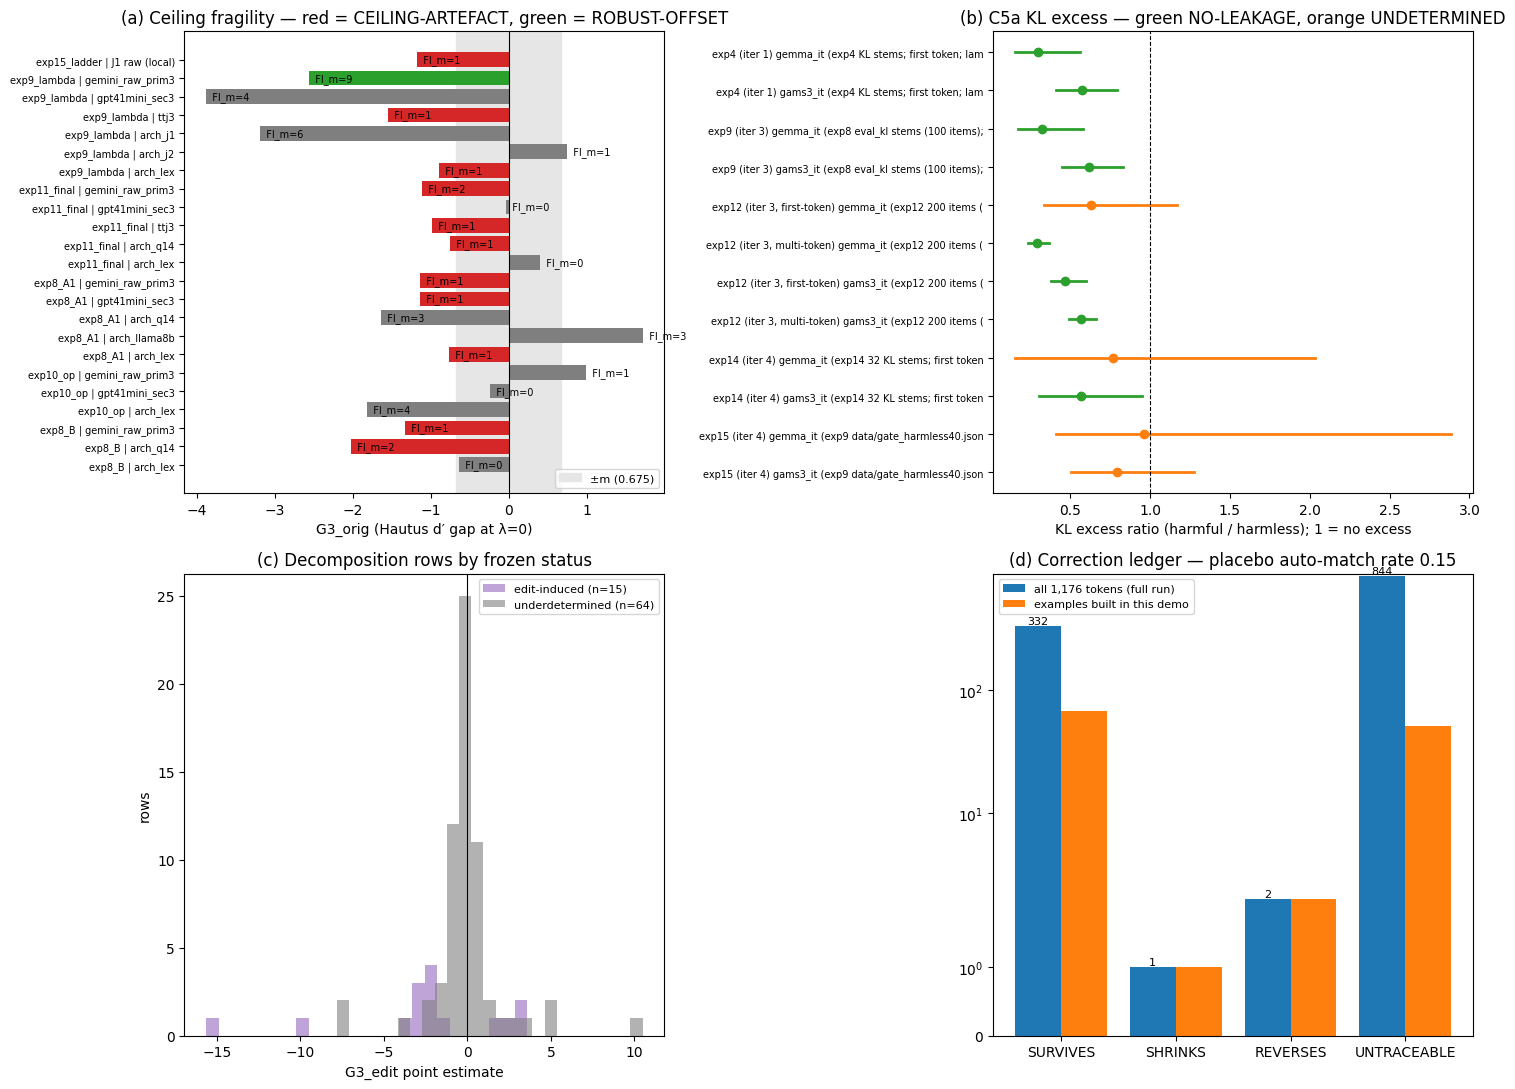

In [10]:
ma = out["metrics_agg"]
groups = {
    "CEILING (exp15)": ["exp15_G3_orig", "exp15_FI_m", "exp15_FI_0", "exp15_prob_did_pp", "exp15_prob_did_pp_ci95_lo",
                        "exp15_prob_did_pp_ci95_hi", "exp15_jeffreys_P_G3orig_lt_minus_m", "exp15_model_perm_p",
                        "exp15_expected_mislabels_4cells", "exp15_ceiling_artefact"],
    "C5a KL excess": ["kl_exp15_gemma_excess", "kl_exp15_gams_excess", "kl_exp14_gemma_excess", "kl_exp14_gemma_ci95_lo",
                      "kl_exp14_gemma_ci95_hi", "kl_exp14_gams_excess", "kl_exp14_gams_ci95_hi", "kl_exp9_gemma_excess",
                      "kl_exp9_gams_excess", "kl_rows_no_leakage", "kl_rows_undetermined", "kl_gpu_gate_pass"],
    "DECOMPOSITION": ["decomp_rows", "decomp_edit_induced", "decomp_baseline", "decomp_underdetermined"],
    "exp14 TABLES": ["exp14_crosscheck_mismatches", "exp14_paper_tables_28_29_values_compared", "exp14_paper_tables_28_29_values_differ"],
    "CRITERION SHIFT": ["crit_rows_total", "crit_rows_invalid_manipulation", "crit_valid_rows_ci_below_0", "crit_valid_rows_ci_above_0"],
    "LEDGER": ["ledger_tokens", "ledger_pointers", "ledger_survives", "ledger_shrinks", "ledger_reverses", "ledger_untraceable",
               "ledger_claim_level_reversals", "ledger_attribution_errors", "ledger_placebo_auto_match_rate"],
    "exp13 / VERIFY": ["exp13_B_overlap", "exp13_C_overlap", "exp13_never_generated", "verify_n_checks", "verify_pass_rate",
                       "openrouter_spend_usd"],
}
rows = [(g, key, ma[key]) for g, keys in groups.items() for key in keys if key in ma]
pd.set_option("display.max_rows", 200)
print(pd.DataFrame(rows, columns=["group", "metric", "value"]).to_string(index=False, float_format=lambda x: f"{x:.4g}"))
print("\neval3 bodies (gemini readout):", {k: round(v, 3) for k, v in ma.items() if k.startswith("eval3_")})
print("\nexamples per dataset:", {dd["dataset"]: len(dd["examples"]) for dd in out["datasets"]})

ds = {dd["dataset"]: dd["examples"] for dd in out["datasets"]}
M = 0.675
fig, ax = plt.subplots(2, 2, figsize=(15, 11))

# (a) ceiling fragility
ce = ds["ceiling_fragility_G3_orig"]
lab = [f"{e['metadata_body']} | {e['metadata_label']}"[:48] for e in ce]
col = ["tab:red" if e["metadata_verdict"] == "CEILING-ARTEFACT" else ("tab:green" if e["metadata_verdict"] == "ROBUST-OFFSET" else "tab:gray") for e in ce]
y = np.arange(len(ce))
ax[0, 0].barh(y, [e["eval_G3_orig"] for e in ce], color=col)
ax[0, 0].axvspan(-M, M, color="0.9", zorder=0, label="±m (0.675)")
for i, e in enumerate(ce):
    ax[0, 0].text(e["eval_G3_orig"], i, f"  FI_m={e['eval_FI_m']:.0f}", va="center", fontsize=7)
ax[0, 0].set_yticks(y, lab, fontsize=7); ax[0, 0].invert_yaxis(); ax[0, 0].axvline(0, color="k", lw=0.8)
ax[0, 0].set_xlabel("G3_orig (Hautus d′ gap at λ=0)")
ax[0, 0].set_title("(a) Ceiling fragility — red = CEILING-ARTEFACT, green = ROBUST-OFFSET")
ax[0, 0].legend(fontsize=8, loc="lower right")

# (b) KL excess forest
kl = ds["c5a_kl_excess_reconciliation"]
y = np.arange(len(kl))
for i, e in enumerate(kl):
    c_ = {"NO-LEAKAGE": "tab:green", "UNDETERMINED": "tab:orange"}.get(e["metadata_verdict"], "tab:gray")
    if e["eval_ci95_lo"] != -1.0:
        ax[0, 1].plot([e["eval_ci95_lo"], e["eval_ci95_hi"]], [i, i], color=c_, lw=2)
    ax[0, 1].plot(e["eval_excess"], i, "o", color=c_)
ax[0, 1].axvline(1.0, color="k", ls="--", lw=0.8)
ax[0, 1].set_yticks(y, [e["input"].replace("C5a excess ratio, ", "")[:55] for e in kl], fontsize=7); ax[0, 1].invert_yaxis()
ax[0, 1].set_xlabel("KL excess ratio (harmful / harmless); 1 = no excess")
ax[0, 1].set_title("(b) C5a KL excess — green NO-LEAKAGE, orange UNDETERMINED")

# (c) decomposition G3_edit by status
de = [e for e in ds["g3_decomposition_table"] if e["eval_G3_edit"] != -999.0]
st_col = {"edit-induced": "tab:purple", "baseline": "tab:blue", "underdetermined": "tab:gray"}
for st in sorted({e["metadata_status"] for e in de}):
    xs = [e["eval_G3_edit"] for e in de if e["metadata_status"] == st]
    ax[1, 0].hist(xs, bins=25, alpha=0.6, label=f"{st} (n={len(xs)})", color=st_col.get(st, "tab:olive"))
ax[1, 0].axvline(0, color="k", lw=0.8)
ax[1, 0].set_xlabel("G3_edit point estimate"); ax[1, 0].set_ylabel("rows")
ax[1, 0].set_title("(c) Decomposition rows by frozen status"); ax[1, 0].legend(fontsize=8)

# (d) ledger status counts: full-run totals vs examples built here
full = {k_: ma.get(f"ledger_{k_.lower()}", 0) for k_ in ("SURVIVES", "SHRINKS", "REVERSES", "UNTRACEABLE")}
here = pd.Series([e["metadata_eval_status"] for e in ds["iter4_paper_correction_ledger"]]).value_counts()
xs = np.arange(4); w = 0.4
ax[1, 1].bar(xs - w / 2, list(full.values()), w, label="all 1,176 tokens (full run)")
ax[1, 1].bar(xs + w / 2, [here.get(k_, 0) for k_ in full], w, label="examples built in this demo")
for i, v_ in enumerate(full.values()):
    ax[1, 1].text(i - w / 2, v_, f"{v_:.0f}", ha="center", va="bottom", fontsize=8)
ax[1, 1].set_xticks(xs, list(full)); ax[1, 1].set_yscale("symlog"); ax[1, 1].legend(fontsize=8)
ax[1, 1].set_title(f"(d) Correction ledger — placebo auto-match rate {ma['ledger_placebo_auto_match_rate']:.2f}")
plt.tight_layout(); plt.show()